# Pool Ball Detection - Task 1

## Step 1: Initialization and Data Loading
This section imports the allowed libraries and loads the pool table images specified in the input JSON file.

### 1.1 Load Libraries

In [271]:
import json
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt


### 1.2 Data Ingestion
Reads the JSON input and loads images into a dictionary, converting them to RGB.

In [272]:
json_file = "input.json" 
loaded_images = {}

with open(json_file, 'r') as f:
    data = json.load(f)

image_list = data.get("image_path", []) if isinstance(data, dict) else data

for full_path in image_list:
    img_bgr = cv2.imread(full_path)
    
    if img_bgr is not None:
        clean_name = os.path.basename(full_path)
        
        loaded_images[clean_name] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded {len(loaded_images)} images.")

Loaded 50 images.


### 1.3 Sanity Check
Displays 3 random images to verify everything loaded correctly.

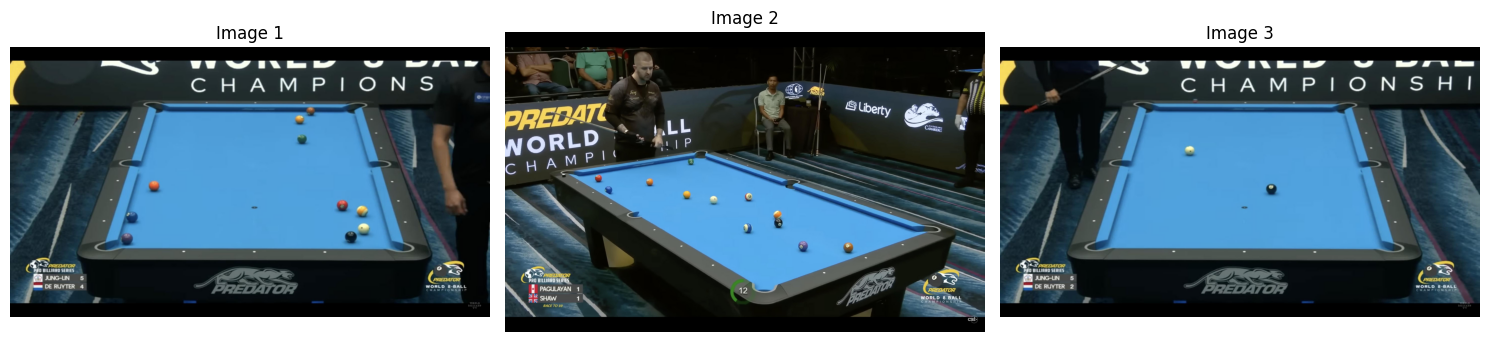

In [273]:
image_paths = list(loaded_images.keys())

first_three_images = image_paths[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
i = 1
for ax, key in zip(axes, first_three_images):
    ax.imshow(loaded_images[key])
    ax.set_title(f"Image {i}", color='black')
    ax.axis('off')
    i += 1

plt.tight_layout()
plt.show()

## Step 2: Top Down View

### 2.1 Table Area Detection
To warp the image, we first need to isolate the playing surface from the background. Instead of hardcoding colors, this function dynamically samples the color at the center of the image. It then uses computer vision techniques (dilation, convex hulls, and erosion) to swallow up the pool balls, straighten the pocket edges, and output a clean, solid mask of just the playable area.

Here we define the function.

In [274]:
# Function to get the table area
def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.

    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    
    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.020))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=2)

    return final_table_mask


### 2.1.1 Visualizing the Table Area Detection Pipeline
To understand how the math works behind the scenes, this section visualizes the intermediate steps of our table detection. The grid below shows exactly how the raw, noisy color threshold is gradually smoothed, filled, and trimmed into a perfect geometric polygon.

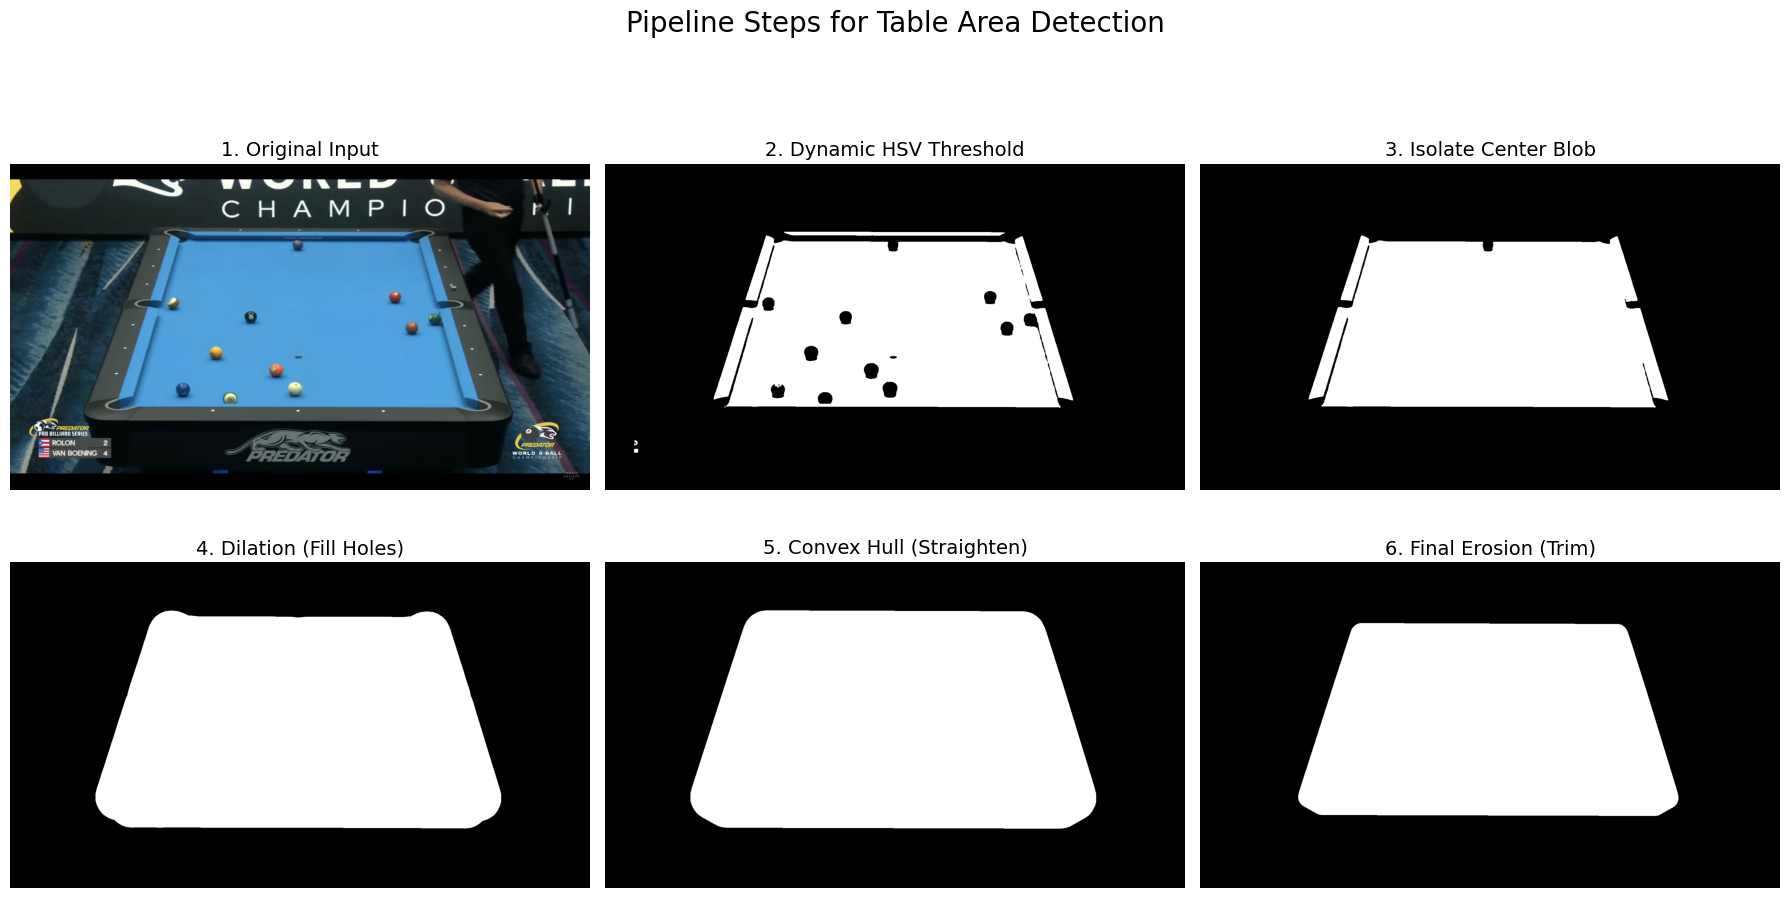

In [275]:
# Visualization of all steps in the pipeline
def get_table_mask_visualized(image_rgb):
    steps = {}
    steps['0_original'] = image_rgb.copy()

    img_h, img_w = image_rgb.shape[:2]
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    cx, cy = img_w // 2, img_h // 2

    # Color Sampling 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)
    
    steps['1_hsv_threshold'] = raw_cloth_mask.copy()

    # Isolate the Table Blob 
    cnts, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        empty = np.zeros((img_h, img_w), dtype=np.uint8)
        return empty, steps

    table_cnt = None
    sorted_cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]
    for c in sorted_cnts:
        if cv2.pointPolygonTest(c, (cx, cy), False) >= 0:
            table_cnt = c
            break
    if table_cnt is None:
        table_cnt = max(cnts, key=cv2.contourArea)

    seed_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(seed_mask, [table_cnt], -1, 255, cv2.FILLED)
    
    steps['2_isolated_center_blob'] = seed_mask.copy()

    # Dilation 
    k = max(25, img_w // 50)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k*2+1, k*2+1))
    dilated_mask = cv2.dilate(seed_mask, kernel, iterations=2)
    
    steps['3_dilated_solid_blob'] = dilated_mask.copy()

    # Convex Hull 
    cnts2, _ = cv2.findContours(dilated_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    hull = cv2.convexHull(max(cnts2, key=cv2.contourArea))
    hull_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(hull_mask, [hull], 255)
    
    steps['4_geometric_convex_hull'] = hull_mask.copy()

    # Erosion 
    ep = max(4, int(min(img_h, img_w) * 0.020))
    e_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ep*2+1, ep*2+1))
    final_eroded_mask = cv2.erode(hull_mask, e_kernel, iterations=2)
    
    steps['5_final_eroded_surface'] = final_eroded_mask.copy()

    return final_eroded_mask, steps

# ═══════════════════════════════════════════════════════════════
#  Visualization Pipeline
# ═══════════════════════════════════════════════════════════════

# Pick a random test image index
test_key = random.choice(image_paths)  
img = loaded_images[test_key]

final_mask, visual_steps = get_table_mask_visualized(img)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel() 

step_keys = sorted(visual_steps.keys())

titles = [
    "1. Original Input",
    "2. Dynamic HSV Threshold",
    "3. Isolate Center Blob",
    "4. Dilation (Fill Holes)",
    "5. Convex Hull (Straighten)",
    "6. Final Erosion (Trim)"
]

for i in range(len(step_keys)):
    key = step_keys[i]
    display_img = visual_steps[key]
    
    if len(display_img.shape) == 3: 
        axes[i].imshow(display_img)
    else: 
        axes[i].imshow(display_img, cmap='gray')
        
    axes[i].set_title(titles[i], color='black', fontsize=14)
    axes[i].axis('off') 

plt.suptitle("Pipeline Steps for Table Area Detection", fontsize=20, color='black')
plt.tight_layout(rect=[0, 0.01, 1, 0.96]) 
plt.show()


### 2.2 Table Corner Extraction
Because our table mask has slightly rounded corners, we cannot simply look for the "tips" of the shape. Instead, this function finds the four straight sides of the table, draws mathematically perfect lines through them, and calculates exactly where those lines cross to find the true, sharp corners.

In [276]:
# ═══════════════════════════════════════════════════════════════
#  Helper Functions
# ═══════════════════════════════════════════════════════════════

# Sorts corners using the center point as reference 
def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

# Line intersection function (returns a point if possible, None if parallel)
def intersect_lines(l1, l2):
    vx1, vy1, x1, y1 = l1
    vx2, vy2, x2, y2 = l2
    
    A1, B1 = vy1, -vx1
    C1 = vy1 * x1 - vx1 * y1
    
    A2, B2 = vy2, -vx2
    C2 = vy2 * x2 - vx2 * y2
    
    det = A1 * B2 - A2 * B1
    if abs(det) < 1e-6:
        return None 
        
    x = (C1 * B2 - C2 * B1) / det
    y = (A1 * C2 - A2 * C1) / det
    return [x, y]

def draw_infinite_line(img, line, color, thickness=2):
    vx, vy, x, y = line
    mult = 3000
    p1 = (int(x - mult * vx), int(y - mult * vy))
    p2 = (int(x + mult * vx), int(y + mult * vy))
    cv2.line(img, p1, p2, color, thickness)

def get_corners_from_mask(table_mask):
    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None
    
    # Order the guideposts: 0:TL, 1:TR, 2:BR, 3:BL
    ordered_guides = order_points_clockwise(guide_corners)
    
    pts = largest_contour.reshape(-1, 2)
    edge_points = [[], [], [], []]
    
    # Assign every pixel to one of the 4 edges
    for pt in pts:
        min_dist = float('inf')
        best_edge = -1
        for i in range(4):
            p1 = ordered_guides[i]
            p2 = ordered_guides[(i + 1) % 4]
            l2 = np.sum((p1 - p2)**2)
            if l2 == 0: continue
            t = max(0, min(1, np.dot(pt - p1, p2 - p1) / l2))
            proj = p1 + t * (p2 - p1)
            dist = np.linalg.norm(pt - proj)
            if dist < min_dist:
                min_dist = dist
                best_edge = i
        edge_points[best_edge].append(pt)
        
    # Fit a line to each edge
    fitted_lines = []
    for i in range(4):
        ep = np.array(edge_points[i])
        if len(ep) < 10: return None
        
        p1 = ordered_guides[i]
        dists = np.linalg.norm(ep - p1, axis=1)
        ep_sorted = ep[np.argsort(dists)]
        
        trim = int(len(ep_sorted) * 0.15)
        if trim > 0:
            ep_trimmed = ep_sorted[trim:-trim]
        else:
            ep_trimmed = ep_sorted
            
        [vx, vy, x, y] = cv2.fitLine(ep_trimmed, cv2.DIST_L2, 0, 0.01, 0.01)
        fitted_lines.append((vx[0], vy[0], x[0], y[0]))
        
    # Intersect the 4 lines to get the new corners
    tl = intersect_lines(fitted_lines[0], fitted_lines[3]) # Top intersects Left
    tr = intersect_lines(fitted_lines[0], fitted_lines[1]) # Top intersects Right
    br = intersect_lines(fitted_lines[1], fitted_lines[2]) # Right intersects Bottom
    bl = intersect_lines(fitted_lines[2], fitted_lines[3]) # Bottom intersects Left
    
    if None in (tl, tr, br, bl): return None
    
    return np.array([tl, tr, br, bl], dtype="float32")


### 2.2.1 Table Corner Extraction Visualization


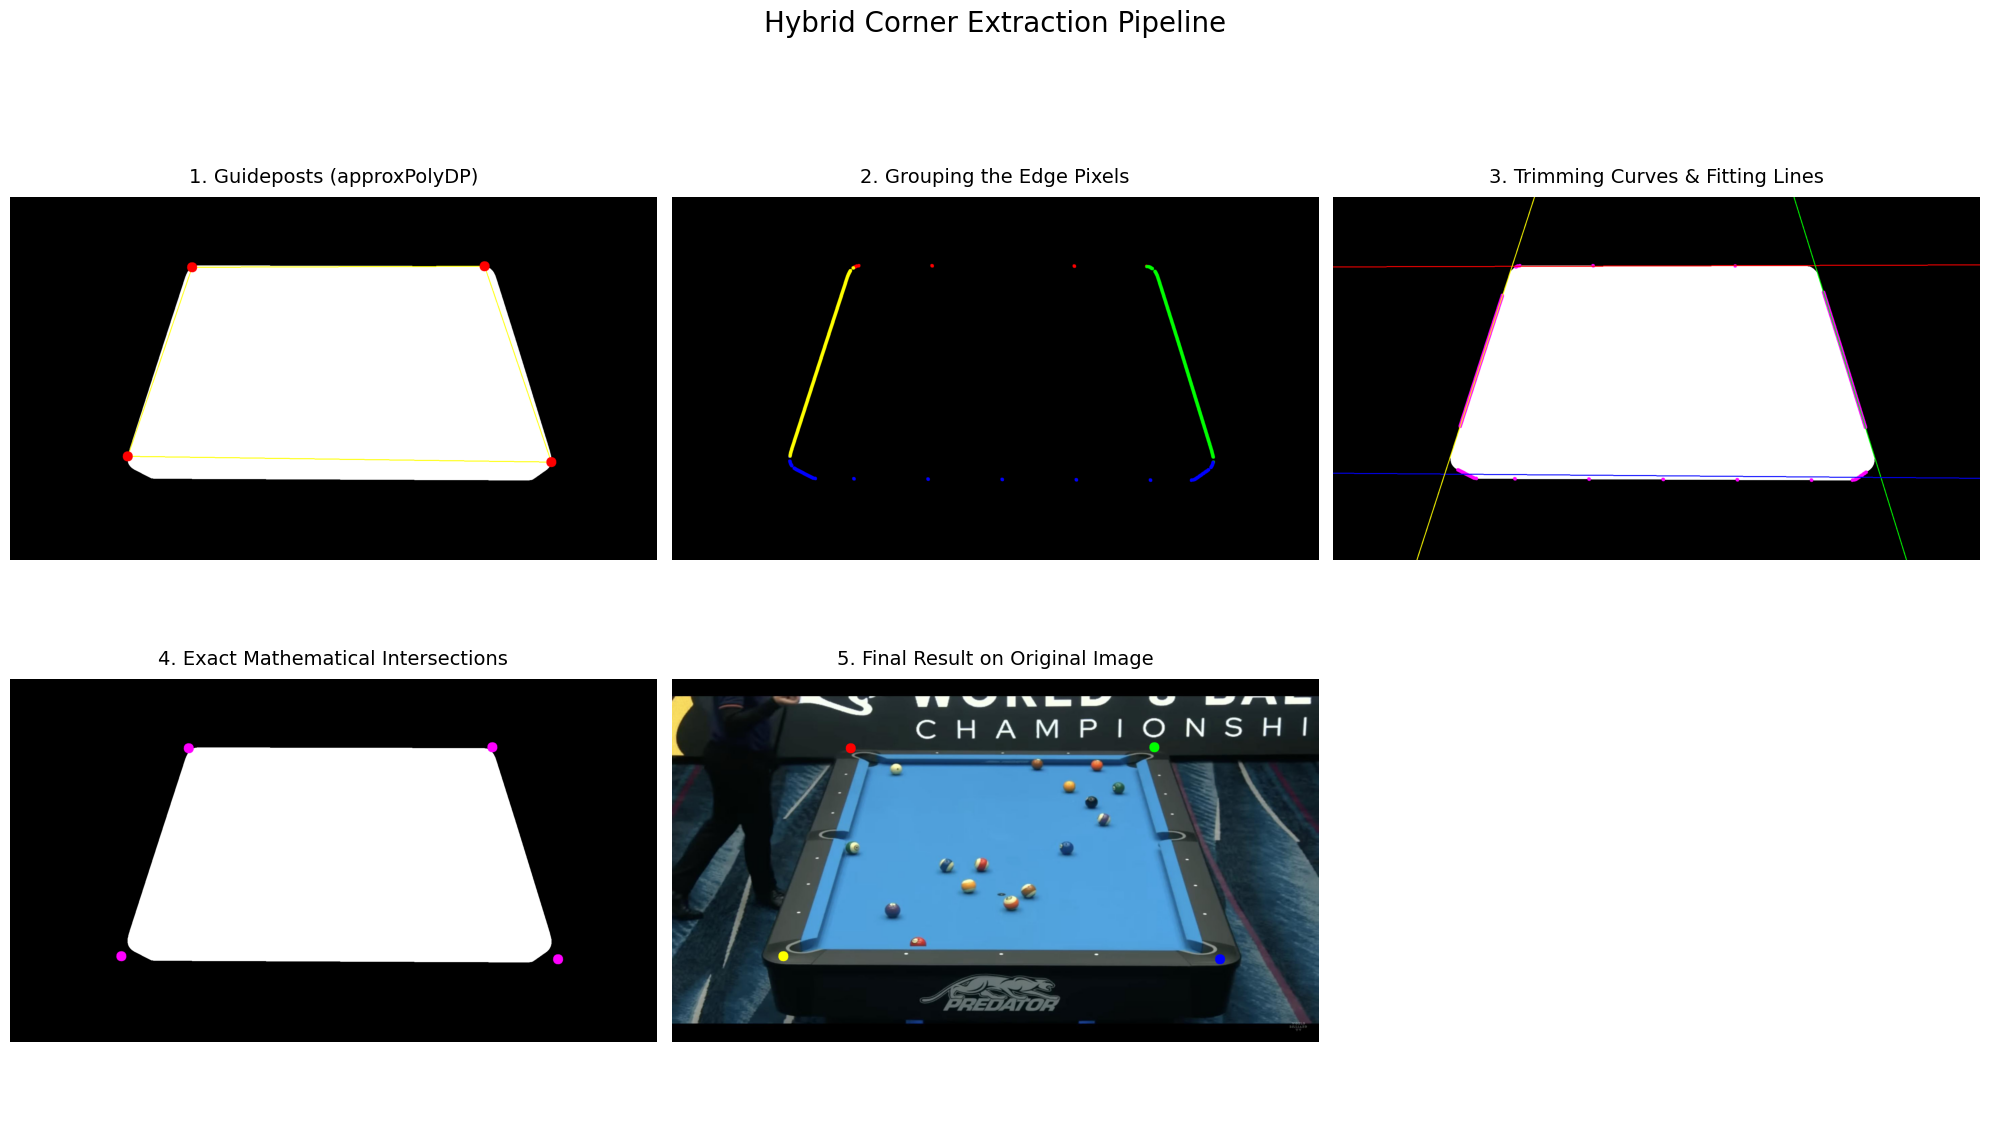

In [277]:
# ═══════════════════════════════════════════════════════════════
#  Visualized Corner Extraction
# ═══════════════════════════════════════════════════════════════

def get_corners_from_mask_visualized(table_mask):
    """Returns the corners AND a dictionary of visual steps."""
    steps = {}
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)
    
    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None, steps
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Guideposts
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None, steps
    ordered_guides = order_points_clockwise(guide_corners)
    
    step1_img = mask_rgb.copy()
    cv2.polylines(step1_img, [np.int32(ordered_guides)], True, (255, 255, 0), 2)
    for pt in ordered_guides:
        cv2.circle(step1_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 0), -1)
    steps['1_guideposts'] = step1_img

    # Edge Pixel Assignment 
    pts = largest_contour.reshape(-1, 2)
    edge_points = [[], [], [], []]
    
    for pt in pts:
        min_dist = float('inf')
        best_edge = -1
        for i in range(4):
            p1 = ordered_guides[i]
            p2 = ordered_guides[(i + 1) % 4]
            l2 = np.sum((p1 - p2)**2)
            if l2 == 0: continue
            t = max(0, min(1, np.dot(pt - p1, p2 - p1) / l2))
            proj = p1 + t * (p2 - p1)
            dist = np.linalg.norm(pt - proj)
            if dist < min_dist:
                min_dist = dist
                best_edge = i
        edge_points[best_edge].append(pt)
        
    step2_img = np.zeros_like(mask_rgb)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i in range(4):
        for pt in edge_points[i]:
            cv2.circle(step2_img, tuple(pt), 5, colors[i], -1)
    steps['2_edge_pixels'] = step2_img

    # Trimming & Fitting Lines 
    fitted_lines = []
    step3_img = mask_rgb.copy()
    
    for i in range(4):
        ep = np.array(edge_points[i])
        if len(ep) < 10: return None, steps
        
        p1 = ordered_guides[i]
        dists = np.linalg.norm(ep - p1, axis=1)
        ep_sorted = ep[np.argsort(dists)]
        
        trim = int(len(ep_sorted) * 0.15)
        if trim > 0:
            ep_trimmed = ep_sorted[trim:-trim]
        else:
            ep_trimmed = ep_sorted
            
        for pt in ep_trimmed:
            cv2.circle(step3_img, tuple(pt), 5, (255, 0, 255), -1)
            
        [vx, vy, x, y] = cv2.fitLine(ep_trimmed, cv2.DIST_L2, 0, 0.01, 0.01)
        line = (vx[0], vy[0], x[0], y[0])
        fitted_lines.append(line)
        
        draw_infinite_line(step3_img, line, colors[i], 2)
        
    steps['3_fitted_lines'] = step3_img

    # Intersecting 
    tl = intersect_lines(fitted_lines[0], fitted_lines[3]) 
    tr = intersect_lines(fitted_lines[0], fitted_lines[1]) 
    br = intersect_lines(fitted_lines[1], fitted_lines[2]) 
    bl = intersect_lines(fitted_lines[2], fitted_lines[3]) 
    
    if None in (tl, tr, br, bl): return None, steps
    final_corners = np.array([tl, tr, br, bl], dtype="float32")
    
    step4_img = mask_rgb.copy()
    for pt in final_corners:
        cv2.circle(step4_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 255), -1)
    steps['4_intersections'] = step4_img
    
    return final_corners, steps


#  Run the Visualization 
test_key = random.choice(image_paths)
test_img = loaded_images[test_key].copy()

test_mask = get_table_mask(test_img)

raw_corners, visual_steps = get_corners_from_mask_visualized(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)
    
    final_display_img = test_img.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i, pt in enumerate(ordered_corners):
        cv2.circle(final_display_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel() 
    
    titles = [
        "1. Guideposts (approxPolyDP)", 
        "2. Grouping the Edge Pixels", 
        "3. Trimming Curves & Fitting Lines", 
        "4. Exact Mathematical Intersections",
        "5. Final Result on Original Image"
    ]
    
    images_to_show = [
        visual_steps['1_guideposts'], 
        visual_steps['2_edge_pixels'], 
        visual_steps['3_fitted_lines'], 
        visual_steps['4_intersections'],
        final_display_img
    ]
    
    for i in range(5):
        axes[i].imshow(images_to_show[i])
        axes[i].set_title(titles[i], color='black', fontsize=14, pad=10)
        axes[i].axis('off')

    axes[5].axis('off')

    plt.suptitle("Hybrid Corner Extraction Pipeline", fontsize=20, color='black')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Could not find corners to visualize.")

### 2.3 Table Warping Pipeline

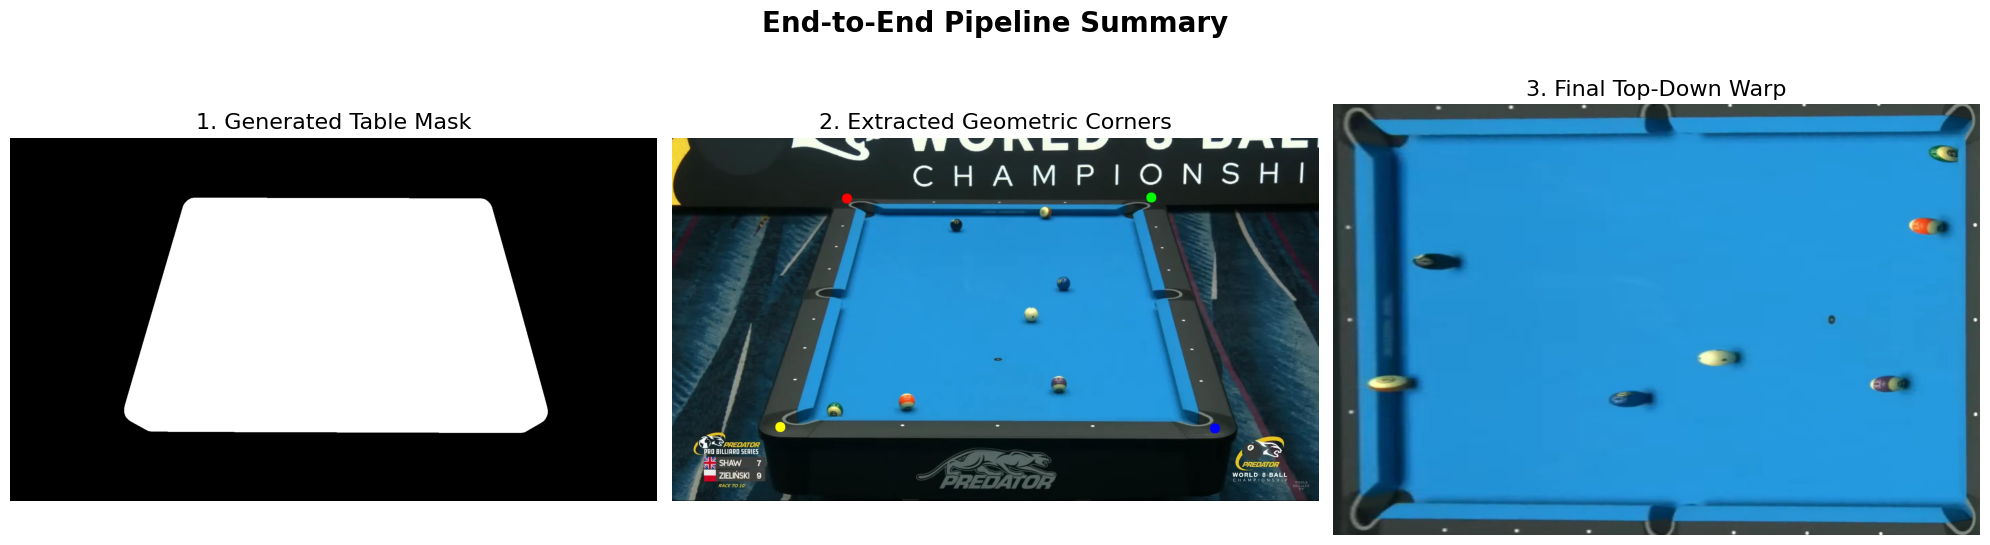

In [278]:
# Warps the 4 corners into an horizontal top-down view.
# Returns the warped image AND the transformation matrix (M) needed for backtracking.
def warp_to_top_down(image_rgb, ordered_corners, width=1200, height=800):
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    
    ratio = top_edge / left_edge
    
    if ratio < 2.2:
        # END-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [0, height - 1],         
            [width - 1, height - 1], 
            [width - 1, 0]           
        ], dtype="float32")
    else:
        # SIDE-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [width - 1, 0],          
            [width - 1, height - 1], 
            [0, height - 1]          
        ], dtype="float32")

    # M is the mathematical map from Original -> Flat
    M = cv2.getPerspectiveTransform(ordered_corners, dst_pts)

    warped = cv2.warpPerspective(image_rgb, M, (width, height), borderMode=cv2.BORDER_REPLICATE)
    
    return warped, M


test_key = random.choice(list(loaded_images.keys()))
test_img = loaded_images[test_key].copy()

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)

corner_img = test_img.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
for i, pt in enumerate(ordered_corners):
    cv2.circle(corner_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
warped_img, _ = warp_to_top_down(test_img, ordered_corners)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.imshow(test_mask, cmap='gray')
ax1.set_title("1. Generated Table Mask", fontsize=16, color='black')
ax1.axis('off')

ax2.imshow(corner_img)
ax2.set_title("2. Extracted Geometric Corners", fontsize=16, color='black')
ax2.axis('off')

ax3.imshow(warped_img)
ax3.set_title("3. Final Top-Down Warp", fontsize=16, color='black')
ax3.axis('off')

plt.suptitle("End-to-End Pipeline Summary", fontsize=20, weight='bold', color='black')
plt.tight_layout()
plt.show()

### 2.4 Save Table Warping Images

In [279]:
# Save warped images
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

print(f"Starting batch process. Saving top-down images to '{output_folder}'...")

success_count = 0
fail_count = 0

homography_matrices = {}

for filename, img_rgb in loaded_images.items():
    test_mask = get_table_mask(img_rgb)
    raw_corners = get_corners_from_mask(test_mask)
    
    if raw_corners is not None:
        ordered_corners = order_points_clockwise(raw_corners)
        
        warped_img, M = warp_to_top_down(img_rgb, ordered_corners)
        
        homography_matrices[filename] = M
        
        warped_bgr = cv2.cvtColor(warped_img, cv2.COLOR_RGB2BGR)
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, warped_bgr)
        
        success_count += 1
    else:
        print(f"Warning: Could not find corners for {filename}")
        fail_count += 1

print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

Starting batch process. Saving top-down images to 'output'...
Batch complete! Warped 50 images. (0 failed)
Successfully saved 50 matrices for backtracking.
